# Import Libraries

In [2]:
import os
import math
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pwlf
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import brevitas.nn as qnn
from brevitas.nn import QuantLinear, QuantReLU, QuantConv2d
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant.binary import SignedBinaryWeightPerTensorConst
from brevitas.inject.enum import QuantType
from brevitas.quant_tensor.int_quant_tensor import IntQuantTensor
from brevitas.function.ops_ste import round_ste
from brevitas.quant import Int8WeightPerChannelFloat

# Network Definition

#### Neuron number and precision in each layer listed in this area for the MLP used in MNIST classification

In [2]:
# -------- Channels --------
kernel_num_CONV_layer_0_0 = 64

kernel_num_CONV_layer_1_0 = 64
kernel_num_CONV_layer_1_1 = 64
kernel_num_CONV_layer_1_2 = 64
kernel_num_CONV_layer_1_3 = 64

kernel_num_CONV_layer_2_0 = 128
kernel_num_CONV_layer_2_1 = 128
kernel_num_CONV_layer_2_2 = 128
kernel_num_CONV_layer_2_3 = 128

kernel_num_CONV_layer_3_0 = 256
kernel_num_CONV_layer_3_1 = 256
kernel_num_CONV_layer_3_2 = 256
kernel_num_CONV_layer_3_3 = 256

kernel_num_CONV_layer_4_0 = 512
kernel_num_CONV_layer_4_1 = 512
kernel_num_CONV_layer_4_2 = 512
kernel_num_CONV_layer_4_3 = 512

kernel_num_CONV_layer_sc2_0 = 128
kernel_num_CONV_layer_sc3_0 = 256
kernel_num_CONV_layer_sc4_0 = 512

# -------- Output classes --------
neuron_num_OUT_layer = 100

# -------- Precisions --------
precision_CONV_layer_0_0 = 4

precision_CONV_layer_1_0 = 4
precision_CONV_layer_1_1 = 4
precision_CONV_layer_1_2 = 4
precision_CONV_layer_1_3 = 4

precision_CONV_layer_2_0 = 1
precision_CONV_layer_2_1 = 1
precision_CONV_layer_2_2 = 1
precision_CONV_layer_2_3 = 1

precision_CONV_layer_3_0 = 1
precision_CONV_layer_3_1 = 1
precision_CONV_layer_3_2 = 1
precision_CONV_layer_3_3 = 1

precision_CONV_layer_4_0 = 1
precision_CONV_layer_4_1 = 1
precision_CONV_layer_4_2 = 1
precision_CONV_layer_4_3 = 1

precision_CONV_layer_sc2_0 = 1
precision_CONV_layer_sc3_0 = 1
precision_CONV_layer_sc4_0 = 1

precision_OUT_layer = 1

#### Hyperparameters setting here.

In [3]:
epochs = 90
batch_sizes = [256]
dropout_rates = [0.0, 0.05, 0.1]
lr_max_pool = [0.001, 0.0005]
lr_min_pool = [0.00001, 0.000001]

#### GPU selection. After decided which GPU to train, don't change it before completing the training

In [4]:
GPU_device = "cuda:0"

#### Training date output folder path, for different network model setting, please change the name of save_path

In [3]:
save_path     = "ResNet18_8bit"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")
IMAGENET_TRAIN_DIR = os.path.join(dataset_root, "ILSVRC2012_img_train")
IMAGENET_VAL_DIR   = os.path.join(dataset_root, "ILSVRC2012_img_val")

print("Dataset Download Path: ", dataset_root, "\n")
print("Train Dataset Path: ", IMAGENET_TRAIN_DIR, "\n")
print("Validation Dataset Path: ", IMAGENET_VAL_DIR, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/ImageNet/dataset 

Train Dataset Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/ImageNet/dataset/ILSVRC2012_img_train 

Validation Dataset Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/ImageNet/dataset/ILSVRC2012_img_val 

Training Data Output Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/ImageNet/train/ResNet18_8bit 

Training Report Output Path:  /home/yuhao/project/new_tutorial/QModels-Brevitas-Example/example/basic_model/classification/ImageNet/report


#### Following are the code to complete the network definition

In [6]:
def int_range(act_bit_width):
    if (act_bit_width>1):
        min_val = -2.0**(act_bit_width-1.0)
        max_val = 2.0**(act_bit_width-1.0)-1.0
    else:
        min_val = -1.0
        max_val = 1.0
    return min_val, max_val

In [7]:
# CIFAR-style stem
kernel_size_stem = 3
kernel_size      = 3

in_channel_0_0    = 3
out_channel_0_0   = kernel_num_CONV_layer_0_0

# Stage 1 (64)
in_channel_1_0    = kernel_num_CONV_layer_0_0
out_channel_1_0   = kernel_num_CONV_layer_1_0
in_channel_1_1    = kernel_num_CONV_layer_1_0
out_channel_1_1   = kernel_num_CONV_layer_1_1
in_channel_1_2    = kernel_num_CONV_layer_1_1
out_channel_1_2   = kernel_num_CONV_layer_1_2
in_channel_1_3    = kernel_num_CONV_layer_1_2
out_channel_1_3   = kernel_num_CONV_layer_1_3

# Stage 2 (128)
in_channel_2_0    = kernel_num_CONV_layer_1_3
out_channel_2_0   = kernel_num_CONV_layer_2_0
in_channel_2_1    = kernel_num_CONV_layer_2_0
out_channel_2_1   = kernel_num_CONV_layer_2_1
in_channel_2_2    = kernel_num_CONV_layer_2_1
out_channel_2_2   = kernel_num_CONV_layer_2_2
in_channel_2_3    = kernel_num_CONV_layer_2_2
out_channel_2_3   = kernel_num_CONV_layer_2_3

# Stage 3 (256)
in_channel_3_0    = kernel_num_CONV_layer_2_3
out_channel_3_0   = kernel_num_CONV_layer_3_0
in_channel_3_1    = kernel_num_CONV_layer_3_0
out_channel_3_1   = kernel_num_CONV_layer_3_1
in_channel_3_2    = kernel_num_CONV_layer_3_1
out_channel_3_2   = kernel_num_CONV_layer_3_2
in_channel_3_3    = kernel_num_CONV_layer_3_2
out_channel_3_3   = kernel_num_CONV_layer_3_3

# Stage 4 (512)
in_channel_4_0    = kernel_num_CONV_layer_3_3
out_channel_4_0   = kernel_num_CONV_layer_4_0
in_channel_4_1    = kernel_num_CONV_layer_4_0
out_channel_4_1   = kernel_num_CONV_layer_4_1
in_channel_4_2    = kernel_num_CONV_layer_4_1
out_channel_4_2   = kernel_num_CONV_layer_4_2
in_channel_4_3    = kernel_num_CONV_layer_4_2
out_channel_4_3   = kernel_num_CONV_layer_4_3

# Shortcut channels (downsample conv1x1)
in_channel_sc2_0   = kernel_num_CONV_layer_1_3
out_channel_sc2_0  = kernel_num_CONV_layer_sc2_0

in_channel_sc3_0   = kernel_num_CONV_layer_2_3
out_channel_sc3_0  = kernel_num_CONV_layer_sc3_0

in_channel_sc4_0   = kernel_num_CONV_layer_3_3
out_channel_sc4_0  = kernel_num_CONV_layer_sc4_0


# ============================================================
# --------- Head dimensions (keep your style) ----------------
# ============================================================
# After global avg pool: [N, C, 1, 1] => C features
input_length  = kernel_num_CONV_layer_4_3
output_length = neuron_num_OUT_layer

In [8]:
conv_0_0_bit_width = precision_CONV_layer_0_0

conv_1_0_bit_width = precision_CONV_layer_1_0
conv_1_1_bit_width = precision_CONV_layer_1_1
conv_1_2_bit_width = precision_CONV_layer_1_2
conv_1_3_bit_width = precision_CONV_layer_1_3

conv_2_0_bit_width = precision_CONV_layer_2_0
conv_2_1_bit_width = precision_CONV_layer_2_1
conv_2_2_bit_width = precision_CONV_layer_2_2
conv_2_3_bit_width = precision_CONV_layer_2_3

conv_3_0_bit_width = precision_CONV_layer_3_0
conv_3_1_bit_width = precision_CONV_layer_3_1
conv_3_2_bit_width = precision_CONV_layer_3_2
conv_3_3_bit_width = precision_CONV_layer_3_3

conv_4_0_bit_width = precision_CONV_layer_4_0
conv_4_1_bit_width = precision_CONV_layer_4_1
conv_4_2_bit_width = precision_CONV_layer_4_2
conv_4_3_bit_width = precision_CONV_layer_4_3

conv_sc2_0_bit_width = precision_CONV_layer_sc2_0
conv_sc3_0_bit_width = precision_CONV_layer_sc3_0
conv_sc4_0_bit_width = precision_CONV_layer_sc4_0

out_bit_width = precision_OUT_layer

In [10]:
class ResNet18(nn.Module):
    def __init__(self, dropout=0.0):
        super(ResNet18, self).__init__()

        # Input quant (keep your style)
        self.input_bin  = qnn.QuantIdentity(
                         quant_type='binary',
                         scaling_impl_type='stats',
                         bit_width=conv_0_0_bit_width,
                         return_quant_tensor=True)
        self.input_quan = qnn.QuantIdentity(
                         quant_type='int',
                         scaling_impl_type='stats',
                         bit_width=conv_0_0_bit_width,
                         return_quant_tensor=True)

        # ---------------- Stem: 7x7 s2 + BN + Act + MaxPool ----------------
        self.conv0_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size_stem,
                         stride=2,
                         padding=3,
                         weight_bit_width=conv_0_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv0_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size_stem,
                         stride=2,
                         padding=3,
                         weight_bit_width=conv_0_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn0_0   = nn.BatchNorm2d(out_channel_0_0)
        self.act0_0  = qnn.QuantReLU(
                         bit_width=conv_1_0_bit_width,
                         return_quant_tensor=True)
        self.drop0_0 = nn.Dropout2d(dropout)

        self.pool0 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # =================================================
        # Stage 1: 2 blocks, channels 64, stride 1
        # =================================================
        # -------- Block 1_0 --------
        self.conv1_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_1_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv1_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_1_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn1_0   = nn.BatchNorm2d(out_channel_1_0)
        self.act1_0  = qnn.QuantReLU(
                         bit_width=conv_1_1_bit_width,
                         return_quant_tensor=True)
        self.drop1_0 = nn.Dropout2d(dropout)

        self.conv1_1_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_1_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv1_1_quan = qnn.QuantConv2d(
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_1_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        # Isolated BN moved to AFTER add => BN+Act pair exists
        self.bn1_1_iso = FakeBatchNorm2d(out_channel_1_1)
        self.act1_1    = qnn.QuantReLU(
                         bit_width=conv_1_2_bit_width,
                         return_quant_tensor=True)
        self.drop1_1   = nn.Dropout2d(dropout)

        # -------- Block 1_1 --------
        self.conv1_2_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_1_2,
                         out_channels=out_channel_1_2,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_1_2_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv1_2_quan = qnn.QuantConv2d(
                         in_channels=in_channel_1_2,
                         out_channels=out_channel_1_2,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_1_2_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn1_2   = nn.BatchNorm2d(out_channel_1_2)
        self.act1_2  = qnn.QuantReLU(
                         bit_width=conv_1_3_bit_width,
                         return_quant_tensor=True)
        self.drop1_2 = nn.Dropout2d(dropout)

        self.conv1_3_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_1_3,
                         out_channels=out_channel_1_3,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_1_3_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv1_3_quan = qnn.QuantConv2d(
                         in_channels=in_channel_1_3,
                         out_channels=out_channel_1_3,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_1_3_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        self.bn1_3_iso = FakeBatchNorm2d(out_channel_1_3)
        self.act1_3    = qnn.QuantReLU(
                         bit_width=conv_2_0_bit_width,
                         return_quant_tensor=True)
        self.drop1_3   = nn.Dropout2d(dropout)

        # =================================================
        # Stage 2: 2 blocks, channels 128, first block stride 2
        # =================================================
        # -------- Block 2_0 (downsample) --------
        self.conv2_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size,
                         stride=2,
                         padding=1,
                         weight_bit_width=conv_2_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv2_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size,
                         stride=2,
                         padding=1,
                         weight_bit_width=conv_2_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn2_0   = nn.BatchNorm2d(out_channel_2_0)
        self.act2_0  = qnn.QuantReLU(
                         bit_width=conv_2_1_bit_width,
                         return_quant_tensor=True)
        self.drop2_0 = nn.Dropout2d(dropout)

        self.conv2_1_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_2_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv2_1_quan = qnn.QuantConv2d(
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_2_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        self.bn2_1_iso = FakeBatchNorm2d(out_channel_2_1)
        self.act2_1    = qnn.QuantReLU(
                         bit_width=conv_2_2_bit_width,
                         return_quant_tensor=True)
        self.drop2_1   = nn.Dropout2d(dropout)

        # Shortcut for downsample (Conv1x1 stride 2)
        self.shortcut2_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_sc2_0,
                         out_channels=out_channel_sc2_0,
                         kernel_size=1,
                         stride=2,
                         padding=0,
                         weight_bit_width=conv_sc2_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.shortcut2_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_sc2_0,
                         out_channels=out_channel_sc2_0,
                         kernel_size=1,
                         stride=2,
                         padding=0,
                         weight_bit_width=conv_sc2_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        # -------- Block 2_1 --------
        self.conv2_2_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_2_2,
                         out_channels=out_channel_2_2,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_2_2_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv2_2_quan = qnn.QuantConv2d(
                         in_channels=in_channel_2_2,
                         out_channels=out_channel_2_2,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_2_2_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn2_2   = nn.BatchNorm2d(out_channel_2_2)
        self.act2_2  = qnn.QuantReLU(
                         bit_width=conv_2_3_bit_width,
                         return_quant_tensor=True)
        self.drop2_2 = nn.Dropout2d(dropout)

        self.conv2_3_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_2_3,
                         out_channels=out_channel_2_3,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_2_3_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv2_3_quan = qnn.QuantConv2d(
                         in_channels=in_channel_2_3,
                         out_channels=out_channel_2_3,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_2_3_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        self.bn2_3_iso = FakeBatchNorm2d(out_channel_2_3)
        self.act2_3    = qnn.QuantReLU(
                         bit_width=conv_3_0_bit_width,
                         return_quant_tensor=True)
        self.drop2_3   = nn.Dropout2d(dropout)

        # =================================================
        # Stage 3: 2 blocks, channels 256, first block stride 2
        # =================================================
        # -------- Block 3_0 (downsample) --------
        self.conv3_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_3_0,
                         out_channels=out_channel_3_0,
                         kernel_size=kernel_size,
                         stride=2,
                         padding=1,
                         weight_bit_width=conv_3_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv3_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_3_0,
                         out_channels=out_channel_3_0,
                         kernel_size=kernel_size,
                         stride=2,
                         padding=1,
                         weight_bit_width=conv_3_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn3_0   = nn.BatchNorm2d(out_channel_3_0)
        self.act3_0  = qnn.QuantReLU(
                         bit_width=conv_3_1_bit_width,
                         return_quant_tensor=True)
        self.drop3_0 = nn.Dropout2d(dropout)

        self.conv3_1_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_3_1,
                         out_channels=out_channel_3_1,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_3_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv3_1_quan = qnn.QuantConv2d(
                         in_channels=in_channel_3_1,
                         out_channels=out_channel_3_1,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_3_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        self.bn3_1_iso = FakeBatchNorm2d(out_channel_3_1)
        self.act3_1    = qnn.QuantReLU(
                         bit_width=conv_3_2_bit_width,
                         return_quant_tensor=True)
        self.drop3_1   = nn.Dropout2d(dropout)

        self.shortcut3_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_sc3_0,
                         out_channels=out_channel_sc3_0,
                         kernel_size=1,
                         stride=2,
                         padding=0,
                         weight_bit_width=conv_sc3_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.shortcut3_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_sc3_0,
                         out_channels=out_channel_sc3_0,
                         kernel_size=1,
                         stride=2,
                         padding=0,
                         weight_bit_width=conv_sc3_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        # -------- Block 3_1 --------
        self.conv3_2_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_3_2,
                         out_channels=out_channel_3_2,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_3_2_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv3_2_quan = qnn.QuantConv2d(
                         in_channels=in_channel_3_2,
                         out_channels=out_channel_3_2,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_3_2_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn3_2   = nn.BatchNorm2d(out_channel_3_2)
        self.act3_2  = qnn.QuantReLU(
                         bit_width=conv_3_3_bit_width,
                         return_quant_tensor=True)
        self.drop3_2 = nn.Dropout2d(dropout)

        self.conv3_3_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_3_3,
                         out_channels=out_channel_3_3,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_3_3_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv3_3_quan = qnn.QuantConv2d(
                         in_channels=in_channel_3_3,
                         out_channels=out_channel_3_3,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_3_3_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        self.bn3_3_iso = FakeBatchNorm2d(out_channel_3_3)
        self.act3_3    = qnn.QuantReLU(
                         bit_width=conv_4_0_bit_width,
                         return_quant_tensor=True)
        self.drop3_3   = nn.Dropout2d(dropout)

        # =================================================
        # Stage 4: 2 blocks, channels 512, first block stride 2
        # =================================================
        # -------- Block 4_0 (downsample) --------
        self.conv4_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_4_0,
                         out_channels=out_channel_4_0,
                         kernel_size=kernel_size,
                         stride=2,
                         padding=1,
                         weight_bit_width=conv_4_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv4_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_4_0,
                         out_channels=out_channel_4_0,
                         kernel_size=kernel_size,
                         stride=2,
                         padding=1,
                         weight_bit_width=conv_4_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn4_0   = nn.BatchNorm2d(out_channel_4_0)
        self.act4_0  = qnn.QuantReLU(
                         bit_width=conv_4_1_bit_width,
                         return_quant_tensor=True)
        self.drop4_0 = nn.Dropout2d(dropout)

        self.conv4_1_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_4_1,
                         out_channels=out_channel_4_1,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_4_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv4_1_quan = qnn.QuantConv2d(
                         in_channels=in_channel_4_1,
                         out_channels=out_channel_4_1,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_4_1_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        self.bn4_1_iso = FakeBatchNorm2d(out_channel_4_1)
        self.act4_1    = qnn.QuantReLU(
                         bit_width=conv_4_2_bit_width,
                         return_quant_tensor=True)
        self.drop4_1   = nn.Dropout2d(dropout)

        self.shortcut4_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_sc4_0,
                         out_channels=out_channel_sc4_0,
                         kernel_size=1,
                         stride=2,
                         padding=0,
                         weight_bit_width=conv_sc4_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.shortcut4_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_sc4_0,
                         out_channels=out_channel_sc4_0,
                         kernel_size=1,
                         stride=2,
                         padding=0,
                         weight_bit_width=conv_sc4_0_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        # -------- Block 4_1 --------
        self.conv4_2_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_4_2,
                         out_channels=out_channel_4_2,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_4_2_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv4_2_quan = qnn.QuantConv2d(
                         in_channels=in_channel_4_2,
                         out_channels=out_channel_4_2,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_4_2_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)
        self.bn4_2   = nn.BatchNorm2d(out_channel_4_2)
        self.act4_2  = qnn.QuantReLU(
                         bit_width=conv_4_3_bit_width,
                         return_quant_tensor=True)
        self.drop4_2 = nn.Dropout2d(dropout)

        self.conv4_3_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_4_3,
                         out_channels=out_channel_4_3,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_4_3_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         bias=False)
        self.conv4_3_quan = qnn.QuantConv2d(
                         in_channels=in_channel_4_3,
                         out_channels=out_channel_4_3,
                         kernel_size=kernel_size,
                         stride=1,
                         padding=1,
                         weight_bit_width=conv_4_3_bit_width,
                         weight_quant_type=QuantType.INT,
                         bias=False)

        self.bn4_3_iso = FakeBatchNorm2d(out_channel_4_3)
        self.act4_3    = qnn.QuantReLU(
                         bit_width=out_bit_width,
                         return_quant_tensor=True)
        self.drop4_3   = nn.Dropout2d(dropout)

        # ---------------- Head: MaxPool2d(7) for ImageNet ----------------
        self.pool_last = nn.MaxPool2d(kernel_size=7, stride=7)

        self.out_bin  = qnn.QuantLinear(
                         in_features=input_length,
                         out_features=output_length,
                         bias=False,
                         weight_bit_width=out_bit_width,
                         weight_quant_type=QuantType.BINARY)
        self.out_quan = qnn.QuantLinear(
                         in_features=input_length,
                         out_features=output_length,
                         bias=False,
                         weight_bit_width=out_bit_width,
                         weight_quant_type=QuantType.INT)

    def forward(self, x):

        if conv_0_0_bit_width == 1:
            out = self.input_bin(x)
        else:
            out = self.input_quan(x)

        # ---------------- Stem ----------------
        if conv_0_0_bit_width == 1:
            out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0_bin(out))))
        else:
            out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0_quan(out))))
        out = self.pool0(out)

        # =================================================
        # Stage 1
        # =================================================
        # -------- Block 1_0 --------
        identity = out

        if conv_1_0_bit_width == 1:
            out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0_bin(out))))
        else:
            out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0_quan(out))))

        if conv_1_1_bit_width == 1:
            out = self.conv1_1_bin(out)
        else:
            out = self.conv1_1_quan(out)

        out = self.drop1_1(self.act1_1(self.bn1_1_iso(out + identity)))

        # -------- Block 1_1 --------
        identity = out

        if conv_1_2_bit_width == 1:
            out = self.drop1_2(self.act1_2(self.bn1_2(self.conv1_2_bin(out))))
        else:
            out = self.drop1_2(self.act1_2(self.bn1_2(self.conv1_2_quan(out))))

        if conv_1_3_bit_width == 1:
            out = self.conv1_3_bin(out)
        else:
            out = self.conv1_3_quan(out)

        out = self.drop1_3(self.act1_3(self.bn1_3_iso(out + identity)))

        # =================================================
        # Stage 2
        # =================================================
        # -------- Block 2_0 (downsample) --------
        if conv_sc2_0_bit_width == 1:
            identity = self.shortcut2_0_bin(out)
        else:
            identity = self.shortcut2_0_quan(out)

        if conv_2_0_bit_width == 1:
            out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0_bin(out))))
        else:
            out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0_quan(out))))

        if conv_2_1_bit_width == 1:
            out = self.conv2_1_bin(out)
        else:
            out = self.conv2_1_quan(out)

        out = self.drop2_1(self.act2_1(self.bn2_1_iso(out + identity)))

        # -------- Block 2_1 --------
        identity = out

        if conv_2_2_bit_width == 1:
            out = self.drop2_2(self.act2_2(self.bn2_2(self.conv2_2_bin(out))))
        else:
            out = self.drop2_2(self.act2_2(self.bn2_2(self.conv2_2_quan(out))))

        if conv_2_3_bit_width == 1:
            out = self.conv2_3_bin(out)
        else:
            out = self.conv2_3_quan(out)

        out = self.drop2_3(self.act2_3(self.bn2_3_iso(out + identity)))

        # =================================================
        # Stage 3
        # =================================================
        # -------- Block 3_0 (downsample) --------
        if conv_sc3_0_bit_width == 1:
            identity = self.shortcut3_0_bin(out)
        else:
            identity = self.shortcut3_0_quan(out)

        if conv_3_0_bit_width == 1:
            out = self.drop3_0(self.act3_0(self.bn3_0(self.conv3_0_bin(out))))
        else:
            out = self.drop3_0(self.act3_0(self.bn3_0(self.conv3_0_quan(out))))

        if conv_3_1_bit_width == 1:
            out = self.conv3_1_bin(out)
        else:
            out = self.conv3_1_quan(out)

        out = self.drop3_1(self.act3_1(self.bn3_1_iso(out + identity)))

        # -------- Block 3_1 --------
        identity = out

        if conv_3_2_bit_width == 1:
            out = self.drop3_2(self.act3_2(self.bn3_2(self.conv3_2_bin(out))))
        else:
            out = self.drop3_2(self.act3_2(self.bn3_2(self.conv3_2_quan(out))))

        if conv_3_3_bit_width == 1:
            out = self.conv3_3_bin(out)
        else:
            out = self.conv3_3_quan(out)

        out = self.drop3_3(self.act3_3(self.bn3_3_iso(out + identity)))

        # =================================================
        # Stage 4
        # =================================================
        # -------- Block 4_0 (downsample) --------
        if conv_sc4_0_bit_width == 1:
            identity = self.shortcut4_0_bin(out)
        else:
            identity = self.shortcut4_0_quan(out)

        if conv_4_0_bit_width == 1:
            out = self.drop4_0(self.act4_0(self.bn4_0(self.conv4_0_bin(out))))
        else:
            out = self.drop4_0(self.act4_0(self.bn4_0(self.conv4_0_quan(out))))

        if conv_4_1_bit_width == 1:
            out = self.conv4_1_bin(out)
        else:
            out = self.conv4_1_quan(out)

        out = self.drop4_1(self.act4_1(self.bn4_1_iso(out + identity)))

        # -------- Block 4_1 --------
        identity = out

        if conv_4_2_bit_width == 1:
            out = self.drop4_2(self.act4_2(self.bn4_2(self.conv4_2_bin(out))))
        else:
            out = self.drop4_2(self.act4_2(self.bn4_2(self.conv4_2_quan(out))))

        if conv_4_3_bit_width == 1:
            out = self.conv4_3_bin(out)
        else:
            out = self.conv4_3_quan(out)

        out = self.drop4_3(self.act4_3(self.bn4_3_iso(out + identity)))

        # ---------------- Head ----------------
        out = self.pool_last(out)  # [N, C, 7, 7] -> [N, C, 1, 1]
        out = out.reshape(out.shape[0], -1)

        if out_bit_width == 1:
            out = self.out_bin(out)
        else:
            out = self.out_quan(out)

        return out

# Random Seed Utility

In [11]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [12]:
test_batch_size = 4096

In [13]:
def get_dataloaders(batch_size):    
    train_dataset = datasets.MNIST(  dataset_root, 
                                     train=True, 
                                     download=True,
                                     transform=transforms.Compose
                                     ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                     ])
                                  )
    test_dataset  = datasets.MNIST( dataset_root, 
                                    train=False, 
                                    download=True,
                                    transform=transforms.Compose
                                    ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                    ])
                                  )
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])
    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(test_dataset, batch_size=test_batch_size),
    )

def get_dataloaders(batch_size, test_batch_size=None, img_size=224):
    if test_batch_size is None:
        test_batch_size = batch_size

    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    train_dataset = datasets.ImageFolder(
        root=IMAGENET_TRAIN_DIR,
        transform=train_transform
    )
    val_dataset = datasets.ImageFolder(
        root=IMAGENET_VAL_DIR,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    test_loader = DataLoader(
        val_dataset,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    return train_loader, val_loader,just inform me two days before test_loader

# Evaluation Pipeline

In [14]:
def evaluate(model, criterion, device, loader, train):
    model.eval()
    loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        if (train):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
        else:
            for x, y in tqdm(loader, desc="Evaluation", leave=True):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [15]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [16]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = MLP(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)

        val_loss, val_acc = evaluate(model, criterion, device, val_loader, train=True)
        train_loss /= total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        #print(log_line)
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f |" % (lr, train_acc, val_acc))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc

# Hyperparameter Searching for Network Training and Testing

In [17]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    # # Generate descending LR combinations
    # lr_combos = [combo for combo in itertools.product(lr_pool, repeat=3)
    #              if (combo[0] > combo[1] > combo[2]) or (combo[0] == combo[1] == combo[2])]
    
    # all_runs = [
    #     f"batch{bs}_lr{lr1}_{lr2}_{lr3}"
    #     for bs, (lr1, lr2, lr3) in itertools.product(batch_sizes, lr_combos)
    # ]
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}"
        for bs, lr_max, lr_min in itertools.product(batch_sizes, lr_max_pool, lr_min_pool)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(report_root, save_path+"_report.csv")):
            os.remove(os.path.join(report_root, save_path+"_report.csv"))
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc = results[0]
    print(f"🏆 Best Config: {best_config} Accuracy: {best_acc:.4f}")
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Config,Accuracy\n")
        for name, acc in results:
            f.write(f"{name},{acc:.4f}\n")

🚀 Running: batch64_lr_max_0.001_min_1e-05_dp0.0


Training:   0%|          | 0/100 [00:00<?, ?it/s]

/home/yuhao/anaconda3/envs/brevitas/lib/python3.9/site-packages/torch/_tensor.py:1362: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /opt/conda/conda-bld/pytorch_1695392022560/work/c10/core/TensorImpl.h:1900.)
  return super().rename(names)


/home/yuhao/anaconda3/envs/brevitas/lib/python3.9/site-packages/brevitas/nn/quant_linear.py:69: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at /opt/conda/conda-bld/pytorch_1695392022560/work/torch/csrc/utils/python_arg_parser.cpp:368.)
  output_tensor = linear(x, quant_weight, quant_bias)


| LR: 0.001000 | Train Acc: 0.5913 | Val Acc: 0.8664 |:   0%|          | 0/100 [00:09<?, ?it/s]

...

| LR: 0.000011 | Train Acc: 0.9992 | Val Acc: 0.9731 |:  99%|█████████▉| 99/100 [13:14<00:08,  8.07s/it]

| LR: 0.000010 | Train Acc: 0.9988 | Val Acc: 0.9704 |:  99%|█████████▉| 99/100 [13:22<00:08,  8.07s/it]

| LR: 0.000010 | Train Acc: 0.9988 | Val Acc: 0.9704 |:  99%|█████████▉| 99/100 [13:22<00:08,  8.07s/it]

| LR: 0.000010 | Train Acc: 0.9988 | Val Acc: 0.9704 |: 100%|██████████| 100/100 [13:22<00:00,  8.16s/it]

| LR: 0.000010 | Train Acc: 0.9988 | Val Acc: 0.9704 |: 100%|██████████| 100/100 [13:22<00:00,  8.03s/it]

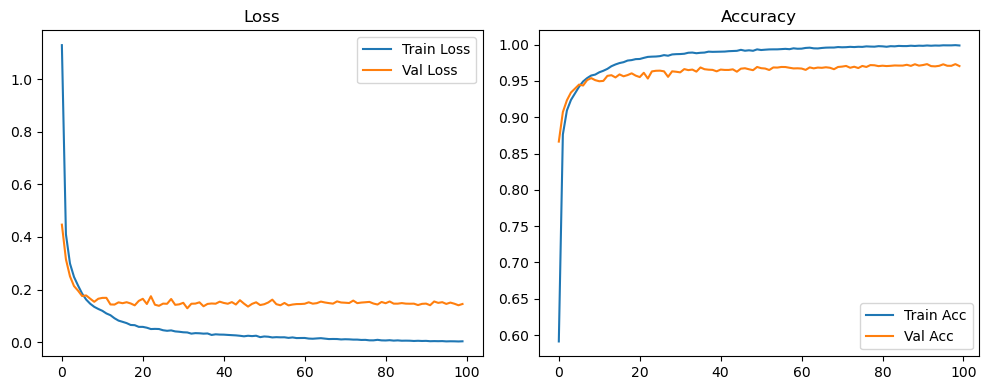

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.01it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.04it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.75it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.50it/s]

...

| LR: 0.000011 | Train Acc: 0.9979 | Val Acc: 0.9704 |:  99%|█████████▉| 99/100 [13:23<00:08,  8.03s/it]

| LR: 0.000010 | Train Acc: 0.9973 | Val Acc: 0.9719 |:  99%|█████████▉| 99/100 [13:31<00:08,  8.03s/it]

| LR: 0.000010 | Train Acc: 0.9973 | Val Acc: 0.9719 |:  99%|█████████▉| 99/100 [13:31<00:08,  8.03s/it]

| LR: 0.000010 | Train Acc: 0.9973 | Val Acc: 0.9719 |: 100%|██████████| 100/100 [13:31<00:00,  8.11s/it]

| LR: 0.000010 | Train Acc: 0.9973 | Val Acc: 0.9719 |: 100%|██████████| 100/100 [13:31<00:00,  8.12s/it]

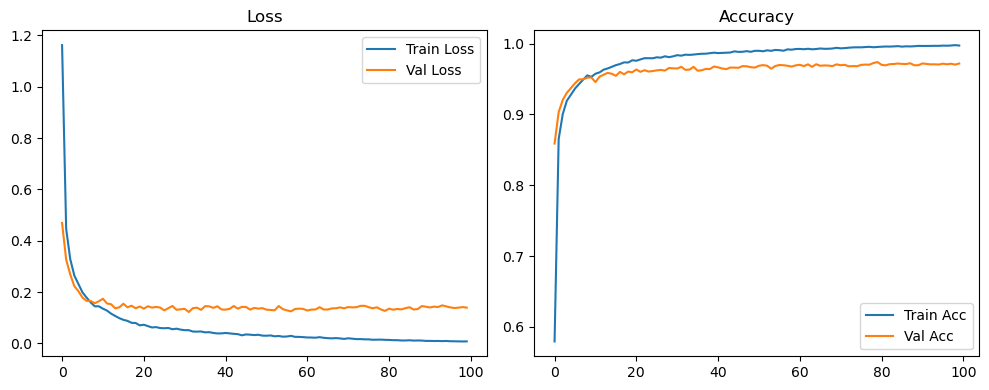

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.57it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.84it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.56it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.26it/s]

...

| LR: 0.000011 | Train Acc: 0.9950 | Val Acc: 0.9714 |:  99%|█████████▉| 99/100 [13:25<00:08,  8.20s/it]

| LR: 0.000010 | Train Acc: 0.9952 | Val Acc: 0.9715 |:  99%|█████████▉| 99/100 [13:33<00:08,  8.20s/it]

| LR: 0.000010 | Train Acc: 0.9952 | Val Acc: 0.9715 |:  99%|█████████▉| 99/100 [13:33<00:08,  8.20s/it]

| LR: 0.000010 | Train Acc: 0.9952 | Val Acc: 0.9715 |: 100%|██████████| 100/100 [13:33<00:00,  8.24s/it]

| LR: 0.000010 | Train Acc: 0.9952 | Val Acc: 0.9715 |: 100%|██████████| 100/100 [13:33<00:00,  8.14s/it]

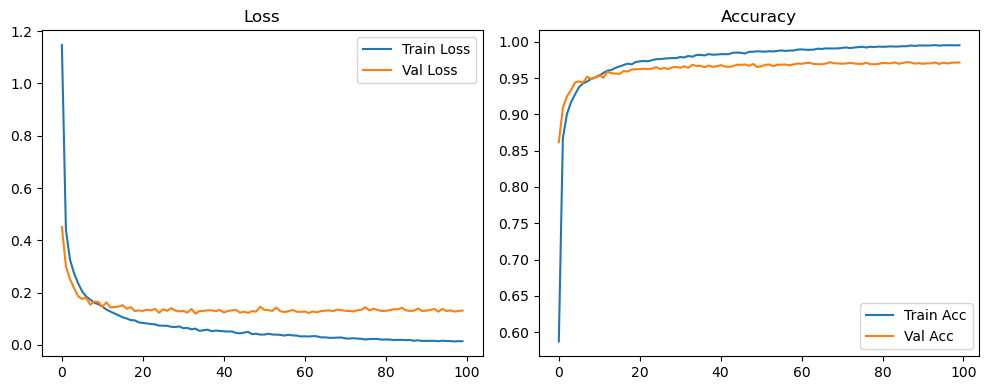

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.04it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.08it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.79it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.54it/s]

...

| LR: 0.000002 | Train Acc: 0.9990 | Val Acc: 0.9729 |:  99%|█████████▉| 99/100 [13:12<00:07,  7.96s/it]

| LR: 0.000001 | Train Acc: 0.9990 | Val Acc: 0.9710 |:  99%|█████████▉| 99/100 [13:20<00:07,  7.96s/it]

| LR: 0.000001 | Train Acc: 0.9990 | Val Acc: 0.9710 |:  99%|█████████▉| 99/100 [13:20<00:07,  7.96s/it]

| LR: 0.000001 | Train Acc: 0.9990 | Val Acc: 0.9710 |: 100%|██████████| 100/100 [13:20<00:00,  7.91s/it]

| LR: 0.000001 | Train Acc: 0.9990 | Val Acc: 0.9710 |: 100%|██████████| 100/100 [13:20<00:00,  8.00s/it]

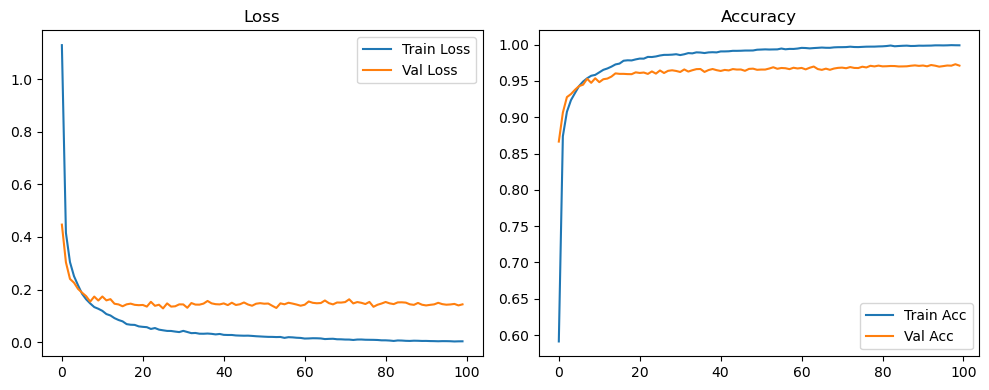

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.03it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.77it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.47it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.27it/s]

...

| LR: 0.000002 | Train Acc: 0.9976 | Val Acc: 0.9733 |:  99%|█████████▉| 99/100 [13:15<00:08,  8.26s/it]

| LR: 0.000001 | Train Acc: 0.9976 | Val Acc: 0.9730 |:  99%|█████████▉| 99/100 [13:23<00:08,  8.26s/it]

| LR: 0.000001 | Train Acc: 0.9976 | Val Acc: 0.9730 |:  99%|█████████▉| 99/100 [13:23<00:08,  8.26s/it]

| LR: 0.000001 | Train Acc: 0.9976 | Val Acc: 0.9730 |: 100%|██████████| 100/100 [13:23<00:00,  8.08s/it]

| LR: 0.000001 | Train Acc: 0.9976 | Val Acc: 0.9730 |: 100%|██████████| 100/100 [13:23<00:00,  8.03s/it]

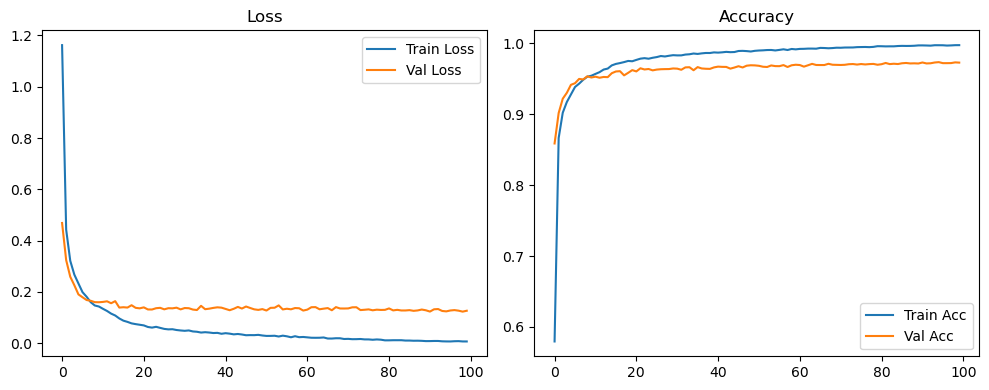

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.94it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.99it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.66it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.43it/s]

...

| LR: 0.000002 | Train Acc: 0.9956 | Val Acc: 0.9737 |:  99%|█████████▉| 99/100 [13:24<00:08,  8.21s/it]

| LR: 0.000001 | Train Acc: 0.9958 | Val Acc: 0.9721 |:  99%|█████████▉| 99/100 [13:32<00:08,  8.21s/it]

| LR: 0.000001 | Train Acc: 0.9958 | Val Acc: 0.9721 |:  99%|█████████▉| 99/100 [13:32<00:08,  8.21s/it]

| LR: 0.000001 | Train Acc: 0.9958 | Val Acc: 0.9721 |: 100%|██████████| 100/100 [13:32<00:00,  8.01s/it]

| LR: 0.000001 | Train Acc: 0.9958 | Val Acc: 0.9721 |: 100%|██████████| 100/100 [13:32<00:00,  8.12s/it]

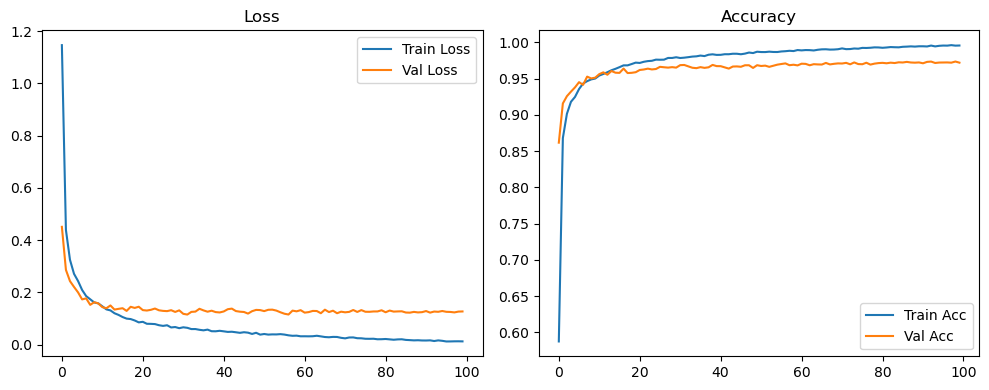

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.84it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.94it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.63it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.38it/s]

...

| LR: 0.000010 | Train Acc: 0.9985 | Val Acc: 0.9695 |:  99%|█████████▉| 99/100 [13:15<00:07,  7.88s/it]

| LR: 0.000010 | Train Acc: 0.9982 | Val Acc: 0.9687 |:  99%|█████████▉| 99/100 [13:23<00:07,  7.88s/it]

| LR: 0.000010 | Train Acc: 0.9982 | Val Acc: 0.9687 |:  99%|█████████▉| 99/100 [13:23<00:07,  7.88s/it]

| LR: 0.000010 | Train Acc: 0.9982 | Val Acc: 0.9687 |: 100%|██████████| 100/100 [13:23<00:00,  7.91s/it]

| LR: 0.000010 | Train Acc: 0.9982 | Val Acc: 0.9687 |: 100%|██████████| 100/100 [13:23<00:00,  8.04s/it]

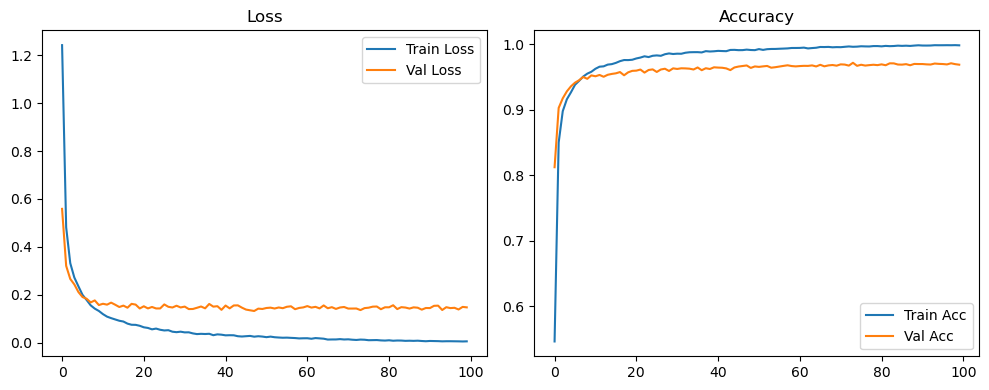

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.98it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.02it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.70it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.47it/s]

...

| LR: 0.000010 | Train Acc: 0.9966 | Val Acc: 0.9704 |:  99%|█████████▉| 99/100 [13:33<00:07,  7.97s/it]

| LR: 0.000010 | Train Acc: 0.9968 | Val Acc: 0.9689 |:  99%|█████████▉| 99/100 [13:41<00:07,  7.97s/it]

| LR: 0.000010 | Train Acc: 0.9968 | Val Acc: 0.9689 |:  99%|█████████▉| 99/100 [13:41<00:07,  7.97s/it]

| LR: 0.000010 | Train Acc: 0.9968 | Val Acc: 0.9689 |: 100%|██████████| 100/100 [13:41<00:00,  7.95s/it]

| LR: 0.000010 | Train Acc: 0.9968 | Val Acc: 0.9689 |: 100%|██████████| 100/100 [13:41<00:00,  8.21s/it]

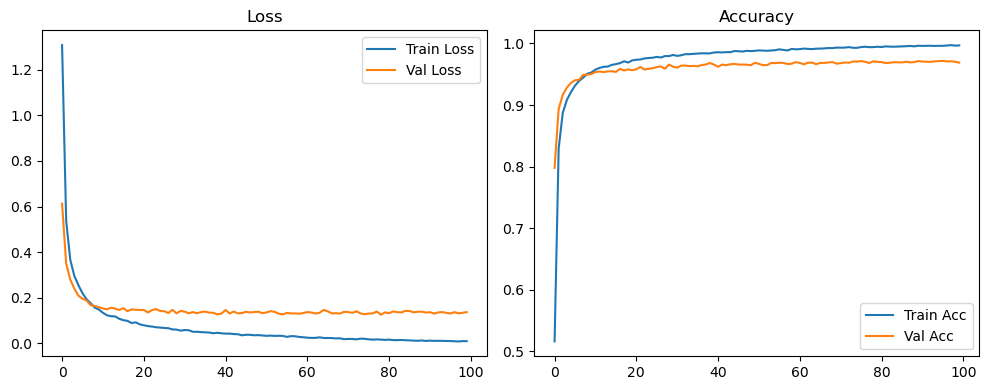

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.98it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  2.00it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.69it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.46it/s]

...

| LR: 0.000010 | Train Acc: 0.9943 | Val Acc: 0.9715 |:  99%|█████████▉| 99/100 [13:13<00:08,  8.23s/it]

| LR: 0.000010 | Train Acc: 0.9940 | Val Acc: 0.9721 |:  99%|█████████▉| 99/100 [13:21<00:08,  8.23s/it]

| LR: 0.000010 | Train Acc: 0.9940 | Val Acc: 0.9721 |:  99%|█████████▉| 99/100 [13:21<00:08,  8.23s/it]

| LR: 0.000010 | Train Acc: 0.9940 | Val Acc: 0.9721 |: 100%|██████████| 100/100 [13:21<00:00,  8.06s/it]

| LR: 0.000010 | Train Acc: 0.9940 | Val Acc: 0.9721 |: 100%|██████████| 100/100 [13:21<00:00,  8.01s/it]

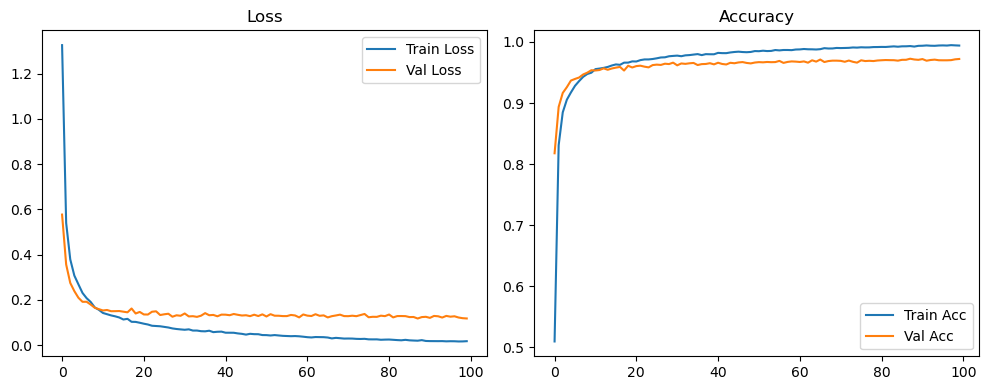

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.00it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.05it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.75it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.51it/s]

...

| LR: 0.000001 | Train Acc: 0.9989 | Val Acc: 0.9717 |:  99%|█████████▉| 99/100 [13:22<00:08,  8.32s/it]

| LR: 0.000001 | Train Acc: 0.9989 | Val Acc: 0.9714 |:  99%|█████████▉| 99/100 [13:30<00:08,  8.32s/it]

| LR: 0.000001 | Train Acc: 0.9989 | Val Acc: 0.9714 |:  99%|█████████▉| 99/100 [13:30<00:08,  8.32s/it]

| LR: 0.000001 | Train Acc: 0.9989 | Val Acc: 0.9714 |: 100%|██████████| 100/100 [13:30<00:00,  8.34s/it]

| LR: 0.000001 | Train Acc: 0.9989 | Val Acc: 0.9714 |: 100%|██████████| 100/100 [13:30<00:00,  8.11s/it]

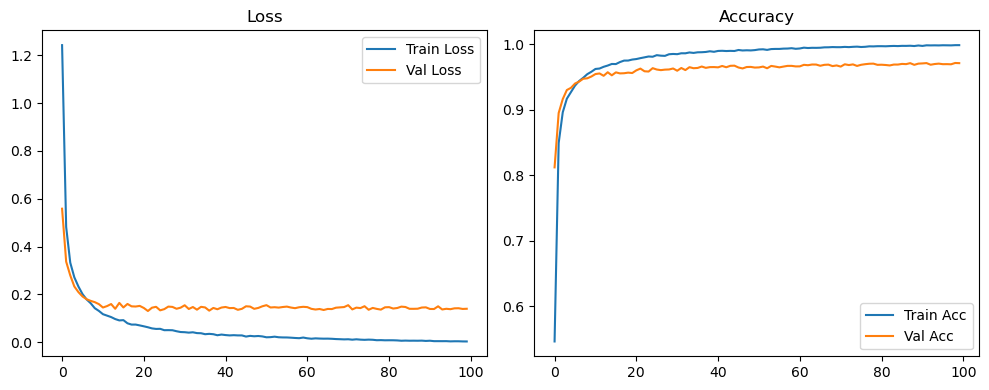

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.97it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.04it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.74it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.50it/s]

...

| LR: 0.000001 | Train Acc: 0.9973 | Val Acc: 0.9708 |:  99%|█████████▉| 99/100 [13:31<00:08,  8.21s/it]

| LR: 0.000001 | Train Acc: 0.9969 | Val Acc: 0.9701 |:  99%|█████████▉| 99/100 [13:39<00:08,  8.21s/it]

| LR: 0.000001 | Train Acc: 0.9969 | Val Acc: 0.9701 |:  99%|█████████▉| 99/100 [13:39<00:08,  8.21s/it]

| LR: 0.000001 | Train Acc: 0.9969 | Val Acc: 0.9701 |: 100%|██████████| 100/100 [13:39<00:00,  8.26s/it]

| LR: 0.000001 | Train Acc: 0.9969 | Val Acc: 0.9701 |: 100%|██████████| 100/100 [13:39<00:00,  8.20s/it]

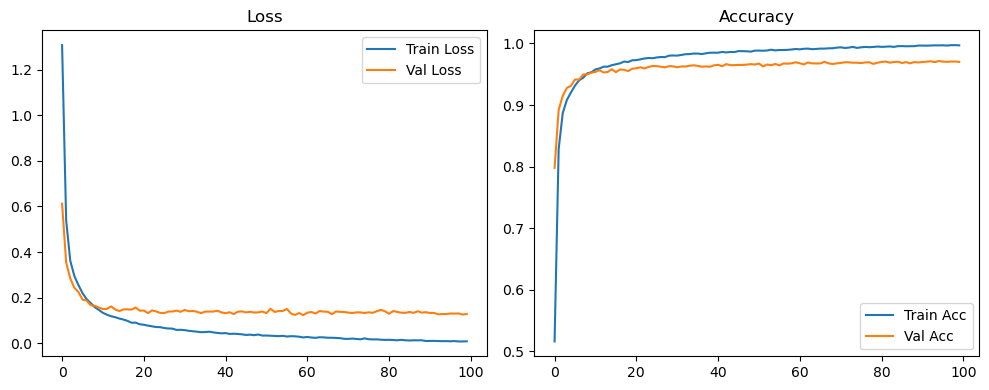

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.98it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.02it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.68it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.46it/s]

...

| LR: 0.000001 | Train Acc: 0.9954 | Val Acc: 0.9722 |:  99%|█████████▉| 99/100 [13:26<00:08,  8.05s/it]

| LR: 0.000001 | Train Acc: 0.9950 | Val Acc: 0.9713 |:  99%|█████████▉| 99/100 [13:34<00:08,  8.05s/it]

| LR: 0.000001 | Train Acc: 0.9950 | Val Acc: 0.9713 |:  99%|█████████▉| 99/100 [13:34<00:08,  8.05s/it]

| LR: 0.000001 | Train Acc: 0.9950 | Val Acc: 0.9713 |: 100%|██████████| 100/100 [13:34<00:00,  8.16s/it]

| LR: 0.000001 | Train Acc: 0.9950 | Val Acc: 0.9713 |: 100%|██████████| 100/100 [13:34<00:00,  8.15s/it]

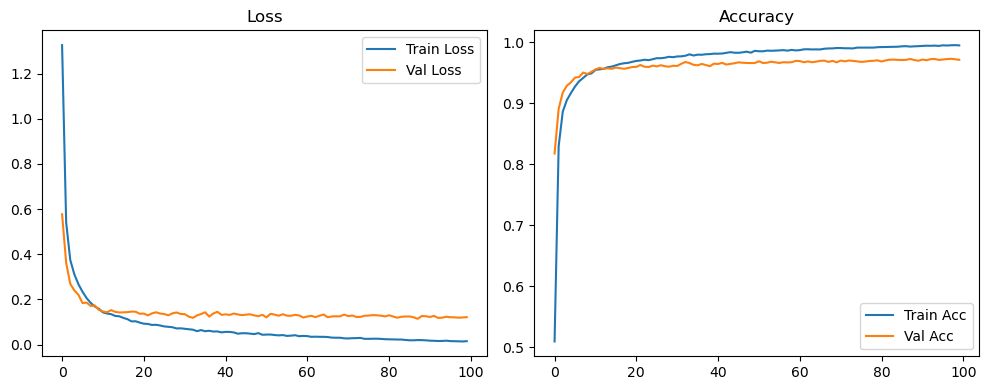

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.99it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.02it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.71it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.48it/s]

Original Model Final Test Loss: 0.1076 Accuracy: 0.9733


🏆 Best Config: batch64_lr_max_0.001_min_1e-05_dp0.1 Accuracy: 0.9766


In [18]:
Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)